# 06. Model Explainability

## Objective

This notebook provides human-interpretable explanations of the trained machine learning model's predictions.

### Goals

- Compute global feature importances across all models
- Apply SHAP (SHapley Additive exPlanations) to explain individual predictions
- Compute permutation feature importances for comparison
- Generate Partial Dependence Plots (PDP) to examine feature relationships
- Create natural-language business explanations for high-risk customers
- Save explainability figures and datasets for business reports

In [1]:
# ==========================================================
# Project Setup & Imports
# ==========================================================

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config.paths import (
    ARTIFACTS_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    REPORTS_EXPLAINABILITY_DIR,
    REPORTS_FIGURES_DIR,
    PROCESSED_DATA_DIR
)

from src.config.settings import RANDOM_STATE, TARGET_COLUMN
from src.explainability.explainability_helper import (
    calculate_model_importance,
    compute_shap_explanations,
    extract_shap_importance,
    compute_permutation_importance,
    generate_comparative_summary,
    generate_local_explanation
)

warnings.filterwarnings("ignore")

# Configure styling
plt.style.use("default")
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

print("Project setup and explainability helpers successfully imported.")

d:\customer-churn-intelligence-platform\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project setup and explainability helpers successfully imported.


In [2]:
# ==========================================================
# Load Saved Artifacts & Processed Dataset
# ==========================================================

model = joblib.load(ARTIFACTS_DIR / "best_model.pkl")
preprocessor = joblib.load(ARTIFACTS_DIR / "preprocessor.pkl")
selected_features = joblib.load(ARTIFACTS_DIR / "selected_features.pkl")

df_processed = pd.read_csv(PROCESSED_DATA_DIR / "ml_dataset_processed.csv")
X = df_processed.drop(columns=TARGET_COLUMN)
y = df_processed[TARGET_COLUMN]

# Align feature names with model selected features list
X_processed = X[selected_features].copy()
feature_names = selected_features

print(f"✓ Loaded preprocessed dataset with shape: {X_processed.shape}")

✓ Loaded preprocessed dataset with shape: (7021, 50)


## 1. Global Model Feature Importance

Retrieving the intrinsic importance values directly from the model weights (coefficients or split importances).

In [3]:
# Compute global importance via weights/coefficients
feature_importance = calculate_model_importance(model, feature_names)

# Add relative percentage scale
max_imp = feature_importance["Importance"].max()
feature_importance["Relative Importance (%)"] = (feature_importance["Importance"] / max_imp) * 100

print("Top 10 Model Features:")
display(feature_importance.head(10))

Top 10 Model Features:


,Feature,Importance,Relative Importance (%)
1,tenure,1.232272,100.000000
43,Contract_Two year,1.216245,98.699349
16,PhoneService_Yes,0.561631,45.576888
3,TotalCharges,0.540914,43.895654
20,InternetService_DSL,0.520038,42.201558
42,Contract_One year,0.420652,34.136323
33,TechSupport_No internet service,0.394851,32.042494
40,StreamingMovies_Yes,0.331610,26.910449
48,PaymentMethod_Electronic check,0.330976,26.858965
44,PaperlessBilling_No,0.321015,26.050679


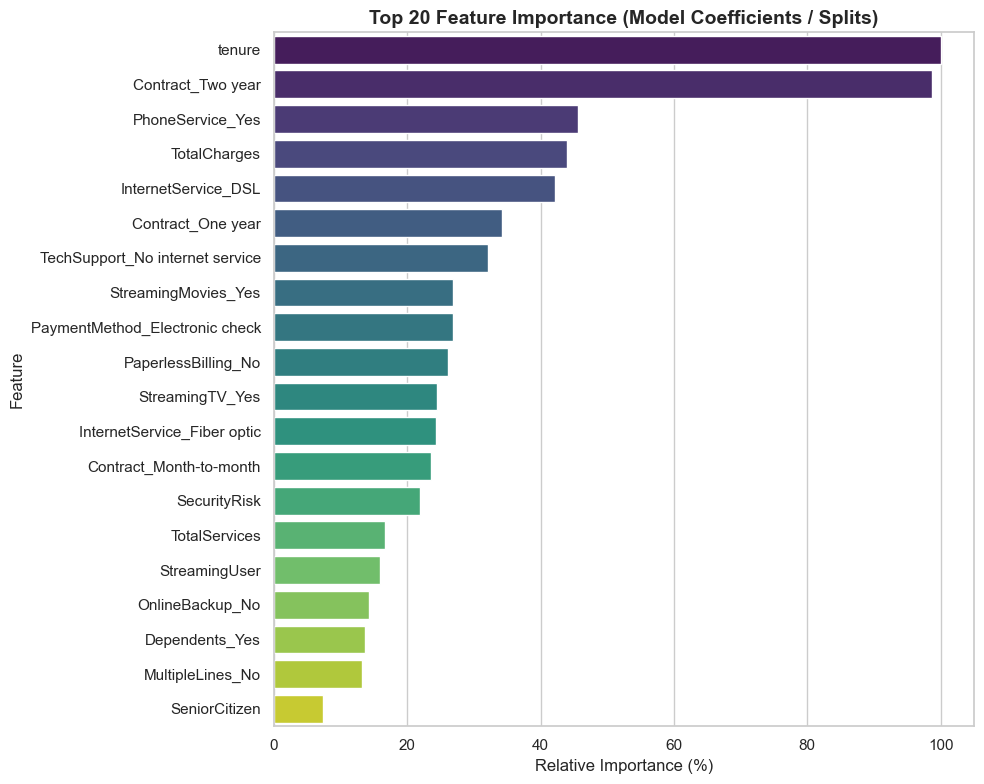

In [4]:
# Plot Global Feature Importance
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(20),
    y="Feature",
    x="Relative Importance (%)",
    palette="viridis",
    hue="Feature",
    legend=False
)
plt.title("Top 20 Feature Importance (Model Coefficients / Splits)", fontsize=14, fontweight="bold")
plt.xlabel("Relative Importance (%)")
plt.ylabel("Feature")
plt.tight_layout()

figures_dir = REPORTS_FIGURES_DIR
figures_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(figures_dir / "feature_importance.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()
plt.close()

## 2. SHAP (SHapley Additive exPlanations) Global Summary

Using game theory to allocate individual model forecast contributions.

In [5]:
# Compute Tree/Linear explainer and explanations
explainer, explanation = compute_shap_explanations(model, X_processed)

# Extract absolute mean SHAP importance matrix
shap_importance = extract_shap_importance(explanation, feature_names)

print("Top 10 SHAP Features:")
display(shap_importance.head(10))

Top 10 SHAP Features:


,Feature,Mean |SHAP Value|
1,tenure,1.096361
3,TotalCharges,0.456750
43,Contract_Two year,0.444583
7,SecurityRisk,0.258583
20,InternetService_DSL,0.250318
8,StreamingUser,0.196557
4,TotalServices,0.178529
40,StreamingMovies_Yes,0.162128
44,PaperlessBilling_No,0.154559
42,Contract_One year,0.154172


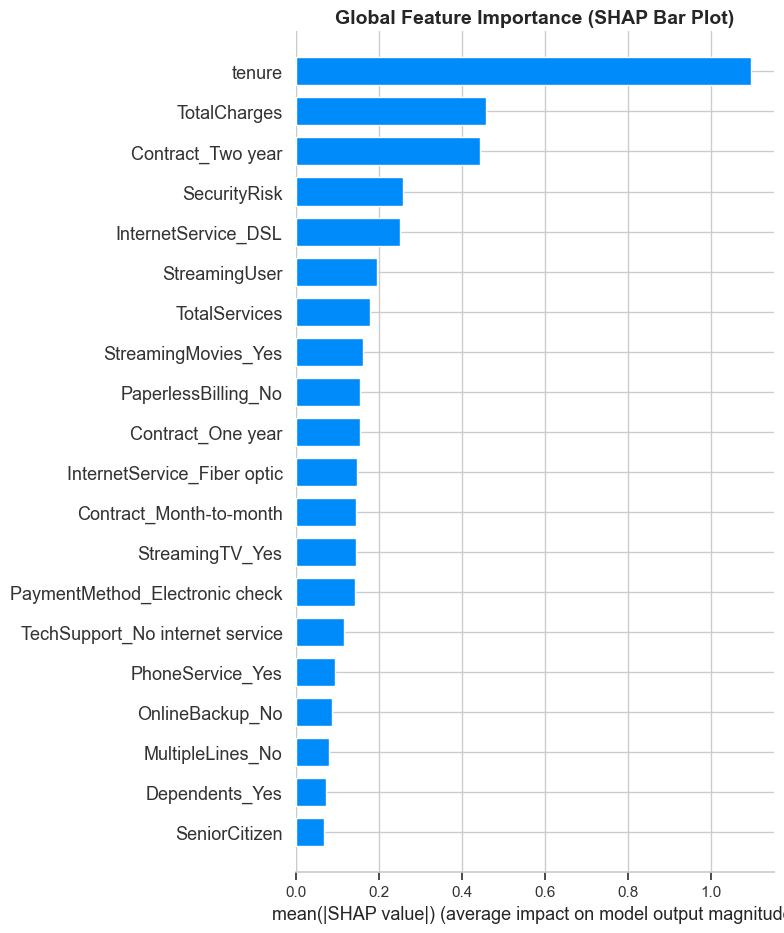

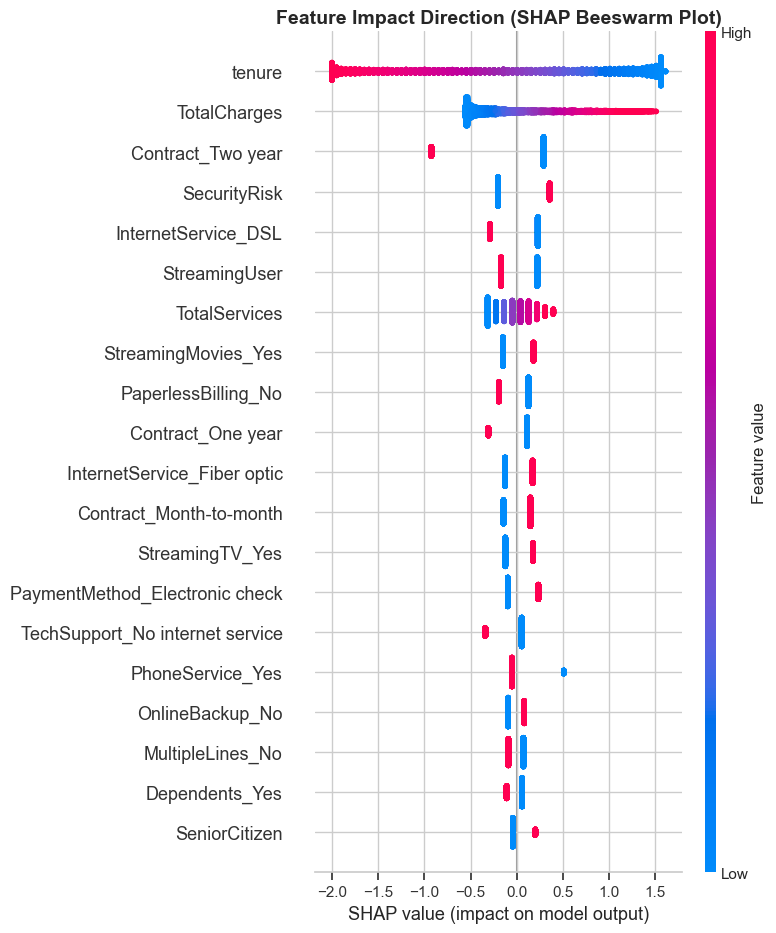

In [6]:
# 1. Renders global absolute mean SHAP bar plot
plt.figure(figsize=(10, 8))
if len(explanation.shape) == 3:
    shap.summary_plot(explanation[:, :, 1], X_processed, plot_type="bar", show=False)
else:
    shap.summary_plot(explanation, X_processed, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP Bar Plot)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(figures_dir / "shap_summary.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()
plt.close()

# 2. Renders global Beeswarm SHAP impact direction plot
plt.figure(figsize=(10, 8))
if len(explanation.shape) == 3:
    shap.summary_plot(explanation[:, :, 1], X_processed, show=False)
else:
    shap.summary_plot(explanation, X_processed, show=False)
plt.title("Feature Impact Direction (SHAP Beeswarm Plot)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(figures_dir / "shap_beeswarm.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()
plt.close()

## 3. Local Customer Explanations

Extracting individual customer profiles and explaining their churn risks automatically.

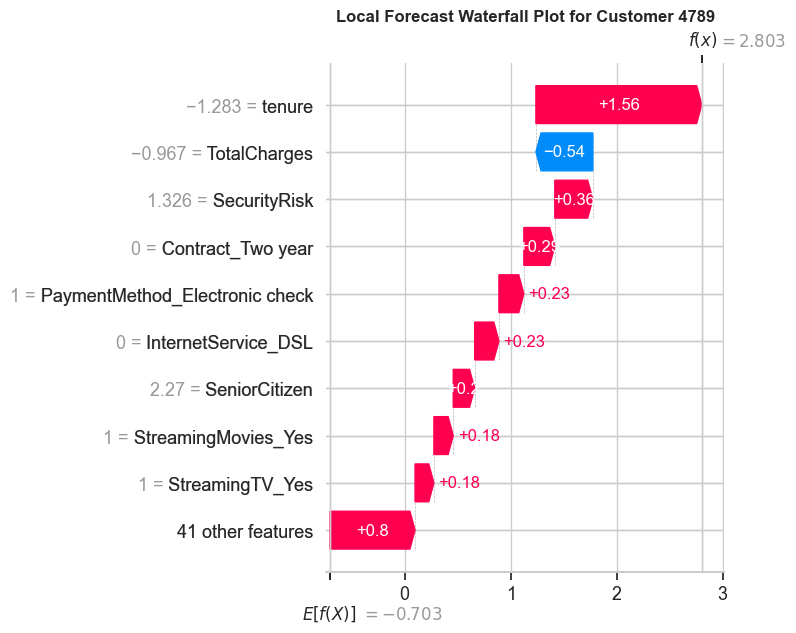

EXECUTIVE DYNAMIC LOCAL CUSTOMER EXPLANATION
Customer Index: 4789
Predicted Churn Probability: 94.3%

Strongest Churn Risk Drivers (Increase Risk):
  - tenure                   : -1.2827    (SHAP impact: +1.5641)
  - SecurityRisk             : 1.3262     (SHAP impact: +0.3586)
  - Contract_Two year        : 0.0000     (SHAP impact: +0.2919)
  - PaymentMethod_Electronic check: 1.0000     (SHAP impact: +0.2350)

Strongest Retention Anchors (Decrease Risk):
  - TotalCharges             : -0.9674    (SHAP impact: -0.5367)
  - StreamingUser            : 1.0033     (SHAP impact: -0.1690)
  - PhoneService_Yes         : 1.0000     (SHAP impact: -0.0505)


In [7]:
# Automatically pick the customer with the highest predicted churn risk
sample_index = np.argmax(model.predict_proba(X_processed)[:, 1])

# Render Waterfall plot
plt.figure(figsize=(10, 6))
if len(explanation.shape) == 3:
    shap.plots.waterfall(explanation[sample_index, :, 1], show=False)
else:
    shap.plots.waterfall(explanation[sample_index], show=False)
plt.title(f"Local Forecast Waterfall Plot for Customer {sample_index}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(figures_dir / "waterfall_plot.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()
plt.close()

# Generate dynamic natural language summary report
report = generate_local_explanation(sample_index, model, X_processed, explanation)
print("=" * 70)
print("EXECUTIVE DYNAMIC LOCAL CUSTOMER EXPLANATION")
print("=" * 70)
print(report)
print("=" * 70)

## 4. Partial Dependence Plots (PDP)

Inspecting the marginal effects of features on predicted probabilities.

Generating PDPs for: ['tenure', 'TotalCharges', 'Contract_Two year']


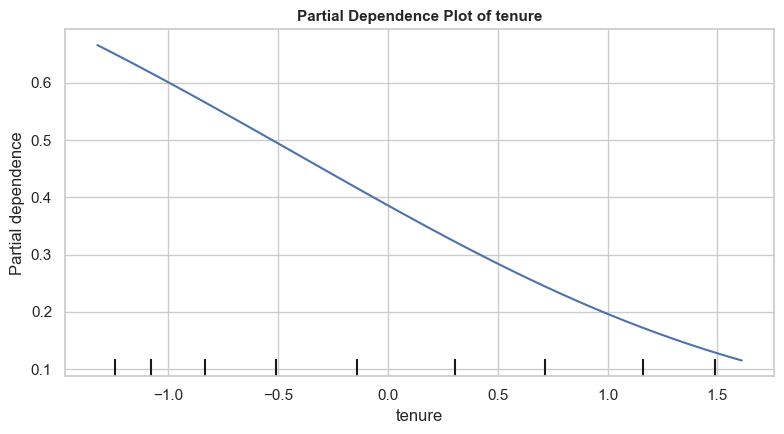

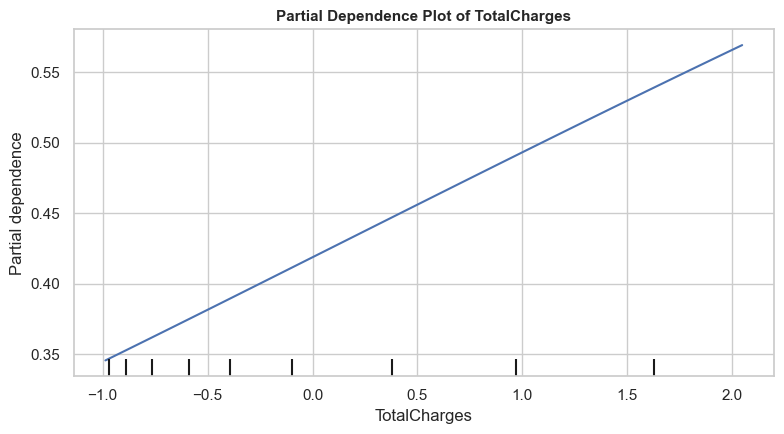

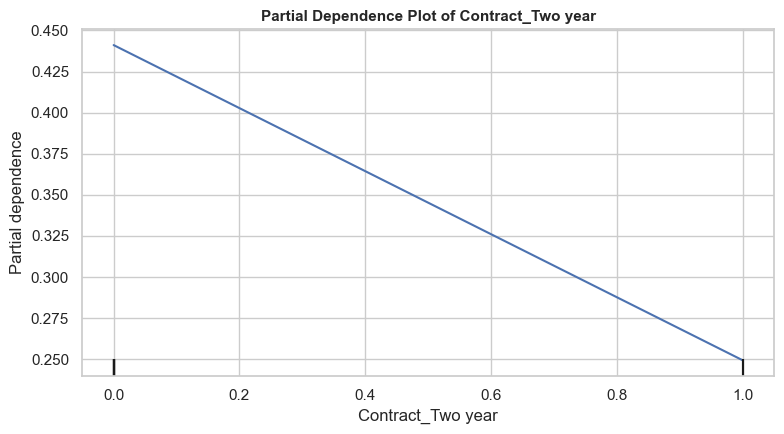

In [8]:
from sklearn.inspection import PartialDependenceDisplay

# Extract top 3 features by absolute SHAP values
pdp_features = shap_importance.head(3)["Feature"].tolist()

print(f"Generating PDPs for: {pdp_features}")

for feature in pdp_features:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    PartialDependenceDisplay.from_estimator(
        model,
        X_processed,
        features=[feature],
        ax=ax,
        kind="average"
    )
    # Safe mapping of names for file path compatibility
    safe_fname = feature.replace(" ", "_").replace("/", "_")
    plt.title(f"Partial Dependence Plot of {feature}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(figures_dir / f"pdp_{safe_fname}.png", dpi=300, facecolor="white", bbox_inches="tight")
    plt.show()
    plt.close()

## 5. Permutation Feature Importance

Measuring the decrease in performance metrics (ROC-AUC) when feature columns are randomly shuffled.

In [9]:
# Compute permutation importance values on-disk
perm_df = compute_permutation_importance(model, X_processed, y, random_state=RANDOM_STATE)

print("Top 10 Permutation Importance Features:")
display(perm_df.head(10))

Top 10 Permutation Importance Features:


,Feature,Importance Mean,Importance Std
1,tenure,0.101823,0.002432
3,TotalCharges,0.015767,0.001906
20,InternetService_DSL,0.008888,0.001102
7,SecurityRisk,0.007563,0.001149
42,Contract_One year,0.004828,0.001790
21,InternetService_Fiber optic,0.002991,0.001437
8,StreamingUser,0.002834,0.001422
37,StreamingTV_Yes,0.002592,0.001636
40,StreamingMovies_Yes,0.002407,0.001241
48,PaymentMethod_Electronic check,0.001951,0.001173


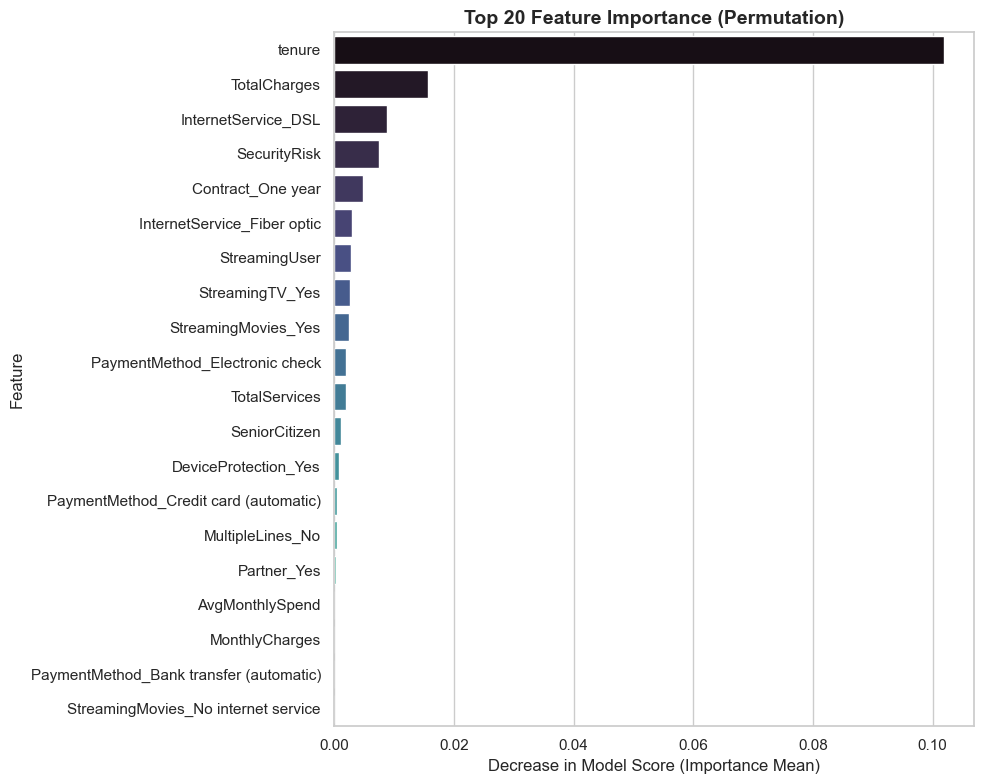

In [10]:
# Plot Permutation Importance
plt.figure(figsize=(10, 8))
sns.barplot(
    data=perm_df.head(20),
    y="Feature",
    x="Importance Mean",
    palette="mako",
    hue="Feature",
    legend=False
)
plt.title("Top 20 Feature Importance (Permutation)", fontsize=14, fontweight="bold")
plt.xlabel("Decrease in Model Score (Importance Mean)")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(figures_dir / "permutation_importance.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()
plt.close()

## 6. Multi-Algorithm Comparatives & Correlations

Validating importance consensus across Model, SHAP, and Permutation metrics.

In [11]:
# Construct merged comparative rank summary table
explainability_summary = generate_comparative_summary(feature_importance, shap_importance, perm_df)

print("Merged Explainability Summary Comparatives:")
display(explainability_summary.head(10))

Merged Explainability Summary Comparatives:


,Feature,Model Importance,Relative Importance (%),Rank_Model,Mean |SHAP Value|,Rank_SHAP,Permutation Importance,Rank_Permutation
0,tenure,1.232272,100.000000,1,1.096361,1,0.101823,1
1,Contract_Two year,1.216245,98.699349,2,0.444583,3,-0.005028,50
2,PhoneService_Yes,0.561631,45.576888,3,0.095282,16,-0.000014,38
3,TotalCharges,0.540914,43.895654,4,0.456750,2,0.015767,2
4,InternetService_DSL,0.520038,42.201558,5,0.250318,5,0.008888,3
5,Contract_One year,0.420652,34.136323,6,0.154172,10,0.004828,5
6,TechSupport_No internet service,0.394851,32.042494,7,0.116503,15,-0.000940,45
7,StreamingMovies_Yes,0.331610,26.910449,8,0.162128,8,0.002407,9
8,PaymentMethod_Electronic check,0.330976,26.858965,9,0.142689,14,0.001951,10
9,PaperlessBilling_No,0.321015,26.050679,10,0.154559,9,-0.000798,44


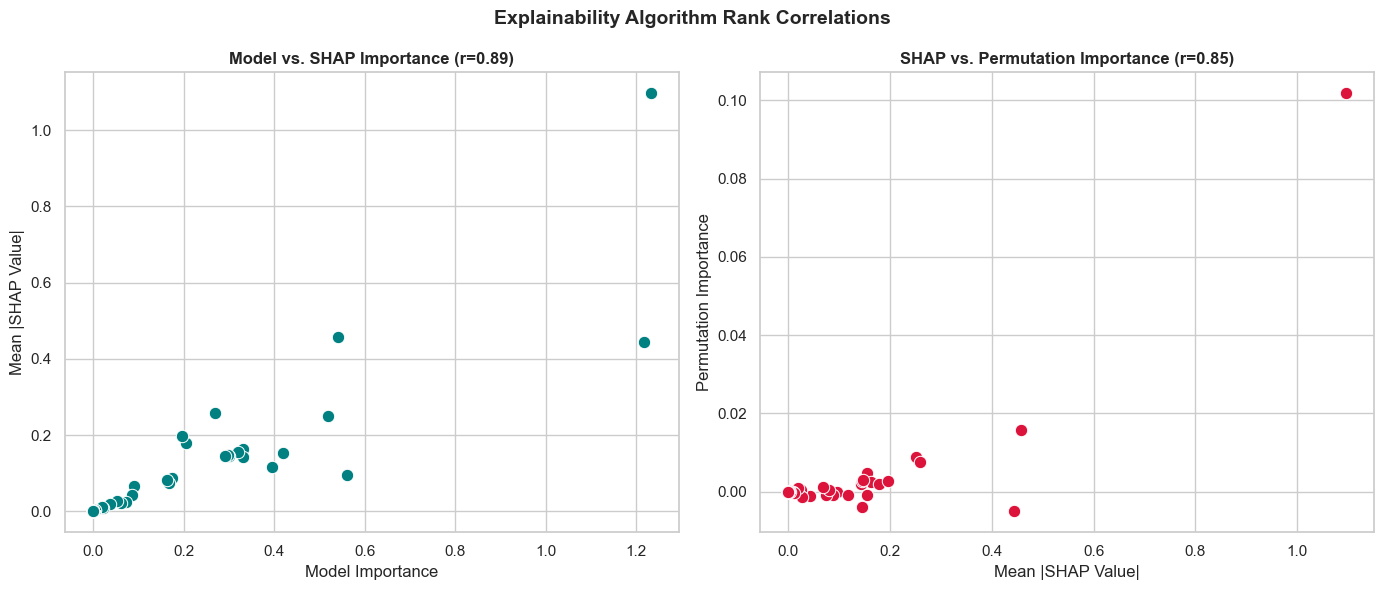

In [12]:
# Renders correlation plots between explainability algorithms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

corr_model_shap = explainability_summary[["Model Importance", "Mean |SHAP Value|"]].corr().iloc[0, 1]
sns.scatterplot(
    data=explainability_summary,
    x="Model Importance",
    y="Mean |SHAP Value|",
    color="teal",
    s=80,
    ax=ax1
)
ax1.set_title(f"Model vs. SHAP Importance (r={corr_model_shap:.2f})", fontsize=12, fontweight="bold")

corr_shap_perm = explainability_summary[["Mean |SHAP Value|", "Permutation Importance"]].corr().iloc[0, 1]
sns.scatterplot(
    data=explainability_summary,
    x="Mean |SHAP Value|",
    y="Permutation Importance",
    color="crimson",
    s=80,
    ax=ax2
)
ax2.set_title(f"SHAP vs. Permutation Importance (r={corr_shap_perm:.2f})", fontsize=12, fontweight="bold")

plt.suptitle("Explainability Algorithm Rank Correlations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(figures_dir / "importance_correlation.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()
plt.close()

In [13]:
# Formats final tabular text report
print("=" * 80)
print(f"{'Feature':<35} {'Model':<12} {'SHAP':<12} {'Permutation':<12}")
print("=" * 80)
for idx, row in explainability_summary.head(10).iterrows():
    print(f"{row['Feature']:<35} {row['Model Importance']:<12.4f} {row['Mean |SHAP Value|']:<12.4f} {row['Permutation Importance']:<12.4f}")
print("=" * 80)

Feature                             Model        SHAP         Permutation 
tenure                              1.2323       1.0964       0.1018      
Contract_Two year                   1.2162       0.4446       -0.0050     
PhoneService_Yes                    0.5616       0.0953       -0.0000     
TotalCharges                        0.5409       0.4568       0.0158      
InternetService_DSL                 0.5200       0.2503       0.0089      
Contract_One year                   0.4207       0.1542       0.0048      
TechSupport_No internet service     0.3949       0.1165       -0.0009     
StreamingMovies_Yes                 0.3316       0.1621       0.0024      
PaymentMethod_Electronic check      0.3310       0.1427       0.0020      
PaperlessBilling_No                 0.3210       0.1546       -0.0008     


In [15]:
# Export CSV metrics and raw arrays
explainability_summary.to_csv(REPORTS_EXPLAINABILITY_DIR / "explainability_summary.csv", index=False)
shap_importance.to_csv(REPORTS_EXPLAINABILITY_DIR / "shap_importance.csv", index=False)
perm_df.to_csv(REPORTS_EXPLAINABILITY_DIR / "permutation_importance.csv", index=False)
feature_importance.to_csv(REPORTS_EXPLAINABILITY_DIR / "feature_importance.csv", index=False)
joblib.dump(explanation.values, ARTIFACTS_DIR / "shap_values.pkl")

print("Explainability summaries and matrices successfully saved on-disk.")

Explainability summaries and matrices successfully saved on-disk.
